In [1]:
import matplotlib
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
import numpy as np
plots.style.use('fivethirtyeight')

# Lecture 28 Designing Experiments

## Review: Lecture 24
From a random sample, construct a 95% confidence interval for the ages of the mothers in the population.

In [2]:
# original sample

births = Table.read_table('baby.csv')
births.show(3)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


In [3]:
# COMPLETE: Create a function that finds a bootstrap sample of the given sample and returns the mean of the mother's age.

def one_bootstrap_mean():
    
    resample = births.sample()
    
    return np.average(resample.column('Maternal Age'))

In [4]:
# COMPLETE: Create a for loop that will generate means from 3000 bootstrap samples
# and store in array named bstrap_means.
num_repetitions = 3000
bstrap_means = make_array()

for i in np.arange(num_repetitions):
    stat = one_bootstrap_mean()
    bstrap_means = np.append(bstrap_means, stat)
    

In [5]:
# COMPLETE: Get the endpoints of the 95% confidence interval

left = percentile(2.5, bstrap_means)
right = percentile(97.5, bstrap_means)

In [6]:
# Display the confidence interval
left, right

(26.885860306643952, 27.566439522998298)

### Interpret the confidence interval. ###

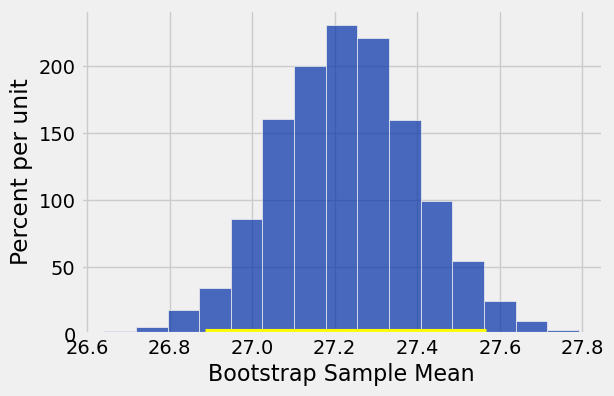

In [7]:
# Display a histogram of the distribution of means. 
# The yellow bar shows where the 95% confidence interval lies.
resampled_means = Table().with_columns(
    'Bootstrap Sample Mean', bstrap_means
)
resampled_means.hist(bins=15)

# Displays the confidence interval, do not edit. 
plots.plot([left, right], [0, 0], color='yellow', lw=8);

## Interpreting a confidence interval: ##

We are <u><em>some</em>%</u> confident that the true <u><em>description of the statistic with the group studied and what study is about</em></u> is between <u><em>low value</em></u> and <u><em>high value</em></u>.

***QUESTION: Use this structure to interpret our confidence interval.***

## Method Based on CLT

Find the left and right value for the Confidence Interval using what we know about the CLT. 

In [9]:
sampled_ages = births.column('Maternal Age')
sample_size = len(sampled_ages)
sample_average = np.average(sampled_ages)
sample_SD = np.std(sampled_ages)
sample_size, sample_average, sample_SD

(1174, 27.228279386712096, 5.8153604041908968)

We need to add and subtract $2*\dfrac{\text{standard of pop}}{\sqrt{\text{sample size}}}$ but we don't have the population SD.

In [10]:
# Try estimating it from the sample

estimated_SD_of_sample_average = sample_SD / np.sqrt(sample_size)
estimated_SD_of_sample_average

0.16972373742299796

In [11]:
# Approximate 95% confidence interval for population mean

confidence_95 = sample_average - 2*estimated_SD_of_sample_average, sample_average + 2*estimated_SD_of_sample_average
confidence_95

(26.888831911866099, 27.567726861558093)

In [12]:
# Recall what the left and right for the 95% was from above.
left, right

(26.885860306643952, 27.566439522998298)

***QUESTION: How close was your sample interval to the original interval?***


## SD of 0/1 Population

***Proportions as Averages***

If the population consists of 1’s and 0’s (yes/no answers to a question), then:

* the population average is the proportion of 1’s in the population
* the sample average is the proportion of 1’s in the sample


In [13]:
# Population of size 10

number_of_ones = 2
zero_one_population = np.append(np.ones(number_of_ones), np.zeros(10 - number_of_ones))

print('Standard Deviation:', np.round(np.std(zero_one_population),2))

zero_one_population

Standard Deviation: 0.4


array([ 1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

In [14]:
def sd_of_zero_one_population(number_of_ones):
    """Returns the SD of a population 
    that has 10 elements: num_ones with value 1 and (10 - num_ones) with value 0"""
    zero_one_population = np.append(np.ones(number_of_ones), 
                                    np.zeros(10 - number_of_ones))
    return np.std(zero_one_population)

In [15]:
possible_ones = np.arange(11)
zero_one_pop = Table().with_columns(
    'Number of Ones', possible_ones,
    'Proportion of Ones', possible_ones / 10
)
zero_one_pop.show()

Number of Ones,Proportion of Ones
0,0
1,0.1
2,0.2
3,0.3
4,0.4
5,0.5
6,0.6
7,0.7
8,0.8
9,0.9


In [16]:
sds = zero_one_pop.apply(sd_of_zero_one_population, 'Number of Ones')
zero_one_pop = zero_one_pop.with_column('Pop SD', sds)
zero_one_pop.show()

Number of Ones,Proportion of Ones,Pop SD
0,0,0
1,0.1,0.3
2,0.2,0.4
3,0.3,0.458258
4,0.4,0.489898
5,0.5,0.5
6,0.6,0.489898
7,0.7,0.458258
8,0.8,0.4
9,0.9,0.3


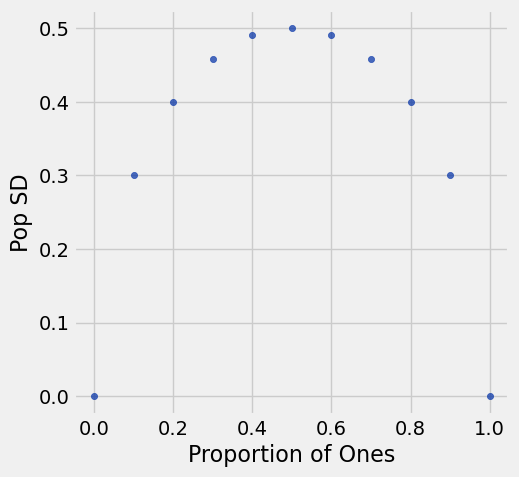

In [17]:
zero_one_pop.scatter('Proportion of Ones', 'Pop SD')

***QUESTION: According to our table and scatterplot, what can we say is the maximum value of our standard deviation for proportions?***


This will be our worst case scenario.

### Connecting to Confidence Intervals

#### Recall:

Interval Width = $\dfrac{4*\text{pop SD}}{\sqrt{\text{sample size}}}$ </br>

Using the worst case scenario, we can find the sample size needed to get a desired width.

Sample Size = $\Bigg(\dfrac{4*\text{pop SD}}{\text{width}}\Bigg)^2$

***QUESTION: Suppose you want the total width of the interval to be no more than 1%. How should you choose the sample size?***

In [19]:
# COMPLETE: Calculate the minimum sample size.
sample_size = (4 * 0.5 / 0.01) ** 2
sample_size

40000.0

### Discussion Question 1

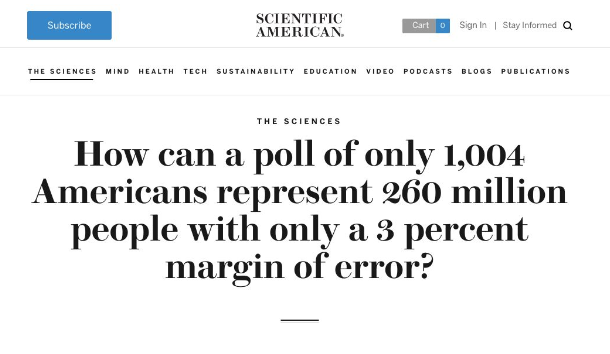

[Article from Scientific American](https://www.scientificamerican.com/article/howcan-a-poll-of-only-100/)

Note: Margin of Error is 2 Standard Deviations.

***QUESTION: What are the two ways to approach this?***

* Using the given width:
* Using the given sample size:


In [22]:
# COMPLETE: Calculate the Sample Size
sample_size2 = (4 * 0.5 / 0.06) ** 2
sample_size2

1111.1111111111113

In [23]:
# COMPLETE: Calculate the Width
width = 4 * 0.5 / np.sqrt(1004)
width

0.063119440309780311

### Discussion Question 2

A researcher is estimating a population proportion based on a random sample of size 10,000. 

Fill in the blank with a decimal:

***QUESTION: With chance at least 95%, the estimate will be correct to within ________________.***

Calculate your answer below: (Remember, Margin of Error is 2 SD, not the entire width)

In [24]:
# COMPLETE: Calculate the Width
width2 = 4 * 0.5 / np.sqrt(10000)
width2

0.02

***QUESTION: What is the Margin of Error?***

?